In [2]:
# VS Code uses KaTeX, which cannot render R's LaTeX list environments.
# Keep HTML/text tables and image plots; apply again on every kernel restart.
options(jupyter.display_mimetypes = setdiff(
    getOption("jupyter.display_mimetypes", c("text/plain", "text/html", "text/markdown", "image/png", "image/jpeg", "image/svg+xml", "application/pdf")),
    "text/latex"
))

library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(harmony)
library(paletteer)
packageVersion("paletteer")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.3 but the current
version is 1.7.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp

• This is Harmony2 version 2.0.5
• Read the guide: run vignette("quickstart", package="harmony")
• Get help: Visit the website at <https://korsunskylab.github.io/harmony2/> and
report issues on <https://github.com/immunogenomics/harmony/issues>


[1] ‘1.7.0’

In [3]:
all <- readRDS("/Users/alex/Library/CloudStorage/OneDrive-Personal/A1_RioLab/01_Projects/02_Codes/1_CIVA/Flex.rds")

In [17]:
colnames(all@meta.data)
unique(all$orig.ident)

[1] "orig.ident"            "nCount_RNA"            "nFeature_RNA"         
[4] "unintegrated_clusters" "seurat_clusters"       "cell_type"

[1] Assembloid VIO       
Levels: Assembloid VIO

In [4]:
# Rename one cell_type level while preserving the exact order
levels(all$cell_type)[levels(all$cell_type) == "FOLR2+ Mac"] <- "Homo Mac"

# Update active identities
Idents(all) <- all$cell_type

# Check the levels to confirm the order is unchanged
levels(all$cell_type)

[1] "CD16+ Mac"    "IL1B+ Mac"    "GLUL+ Mac"    "Homo Mac"     "TREM2+ Mac"  
 [6] "FABP5+ Mac"   "C3+ Mac"      "ISG15+ Mac"   "HK2+ Mac"     "GAS6+ Mac"   
[11] "CSF3R+ Mac"   "NR4A1+ Mac"   "Prolif Mac-1" "Prolif Mac-2" "Prolif Mac-3"
[16] "Mast_cell"    "Fibroblast"   "Endothelium"  "Tumor"        "Mixed"       
[21] "Unknown_1"    "Unknown_2"

In [19]:
# View the exact R call string and parameters
all@commands$RunPCA@params
all@commands$RunUMAP@params

$assay
[1] "RNA"

$npcs
[1] 50

$rev.pca
[1] FALSE

$weight.by.var
[1] TRUE

$verbose
[1] TRUE

$ndims.print
[1] 1 2 3 4 5

$nfeatures.print
[1] 30

$reduction.name
[1] "pca"

$reduction.key
[1] "PC_"

$seed.use
[1] 42

$dims
 [1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50

$reduction
[1] "pca"

$assay
[1] "RNA"

$slot
[1] "data"

$umap.method
[1] "uwot"

$return.model
[1] FALSE

$n.neighbors
[1] 30

$n.components
[1] 2

$metric
[1] "cosine"

$learning.rate
[1] 1

$min.dist
[1] 0.3

$spread
[1] 1

$set.op.mix.ratio
[1] 1

$local.connectivity
[1] 1

$repulsion.strength
[1] 1

$negative.sample.rate
[1] 5

$uwot.sgd
[1] FALSE

$seed.use
[1] 42

$angular.rp.forest
[1] FALSE

$densmap
[1] FALSE

$dens.lambda
[1] 2

$dens.frac
[1] 0.3

$dens.var.shift
[1] 0.1

$verbose
[1] TRUE

$reduction.name
[1] "umap.unintegrated"

In [20]:
# View the summary stats (Min, Median, Max, etc.) for counts and features
summary(all@meta.data[, c("nCount_RNA", "nFeature_RNA")])

   nCount_RNA      nFeature_RNA  
 Min.   :   457   Min.   :  206  
 1st Qu.: 10004   1st Qu.: 4013  
 Median : 14906   Median : 4914  
 Mean   : 17312   Mean   : 4832  
 3rd Qu.: 21588   3rd Qu.: 5797  
 Max.   :262966   Max.   :11241  

In [21]:
levels(all@meta.data$cell_type)
levels(all@meta.data$orig.ident)

[1] "CD16+ Mac"    "IL1B+ Mac"    "GLUL+ Mac"    "Homo Mac"     "TREM2+ Mac"  
 [6] "FABP5+ Mac"   "C3+ Mac"      "ISG15+ Mac"   "HK2+ Mac"     "GAS6+ Mac"   
[11] "CSF3R+ Mac"   "NR4A1+ Mac"   "Prolif Mac-1" "Prolif Mac-2" "Prolif Mac-3"
[16] "Mast_cell"    "Fibroblast"   "Endothelium"  "Tumor"        "Mixed"       
[21] "Unknown_1"    "Unknown_2"

[1] "Assembloid" "VIO"

In [22]:
all_full<-all

In [23]:
library(paletteer)
packageVersion("paletteer")

[1] ‘1.7.0’

In [5]:
all$cell_type <- Idents(all)
levels(all$cell_type)[levels(all$cell_type) == "CD16+ Mac"] <- "FOLR2+ Mac"

In [6]:
# Remove unwanted cell types
all <- subset(
  all,
  subset = !cell_type %in% c("Mixed", "Unknown_1", "Unknown_2")
)
cell_types <- levels(all$cell_type)
all$cell_type <- as.character(all$cell_type)
all$cell_type[all$cell_type %in% c("Prolif Mac-2", "Prolif Mac-1", "Prolif Mac-3")] <- "MKI67+ Mac"
all$cell_type[all$cell_type == "CD16+ Mac"] <- "FOLR2+ Mac"
# Remove unused factor levels
cell_types[cell_types %in% c("Prolif Mac-2", "Prolif Mac-1", "Prolif Mac-3")] <- "MKI67+ Mac"
cell_types[cell_types == "CD16+ Mac"] <- "FOLR2+ Mac"
all$cell_type <- factor(all$cell_type, levels = unique(cell_types))

In [7]:
# Reproduce scCustomize::DiscretePalette_scCustomize(..., palette = "stepped")
# directly from its underlying pals::stepped palette via paletteer.
cell_types <- levels(Idents(all))
all$cell_type <- as.character(Idents(all))
all$cell_type[all$cell_type %in% c("Prolif Mac-2", "Prolif Mac-1", "Prolif Mac-3")] <- "MKI67+ Mac"
all$cell_type[all$cell_type == "CD16+ Mac"] <- "FOLR2+ Mac"
cell_types[cell_types %in% c("Prolif Mac-2", "Prolif Mac-1", "Prolif Mac-3")] <- "MKI67+ Mac"
cell_types[cell_types == "CD16+ Mac"] <- "FOLR2+ Mac"
cell_types <- unique(cell_types)
all$cell_type <- factor(all$cell_type, levels = cell_types)
pal <- as.character(paletteer_d("pals::stepped", 24))[seq_len(length(cell_types))]
names(pal) <- cell_types

In [27]:
unique(all$cell_type)

[1] FOLR2+ Mac  HK2+ Mac    IL1B+ Mac   TREM2+ Mac  GLUL+ Mac   Endothelium
 [7] CSF3R+ Mac  GAS6+ Mac   Tumor       Fibroblast  Homo Mac    ISG15+ Mac 
[13] Mast_cell   NR4A1+ Mac  MKI67+ Mac  C3+ Mac     FABP5+ Mac 
17 Levels: FOLR2+ Mac IL1B+ Mac GLUL+ Mac Homo Mac TREM2+ Mac ... Tumor

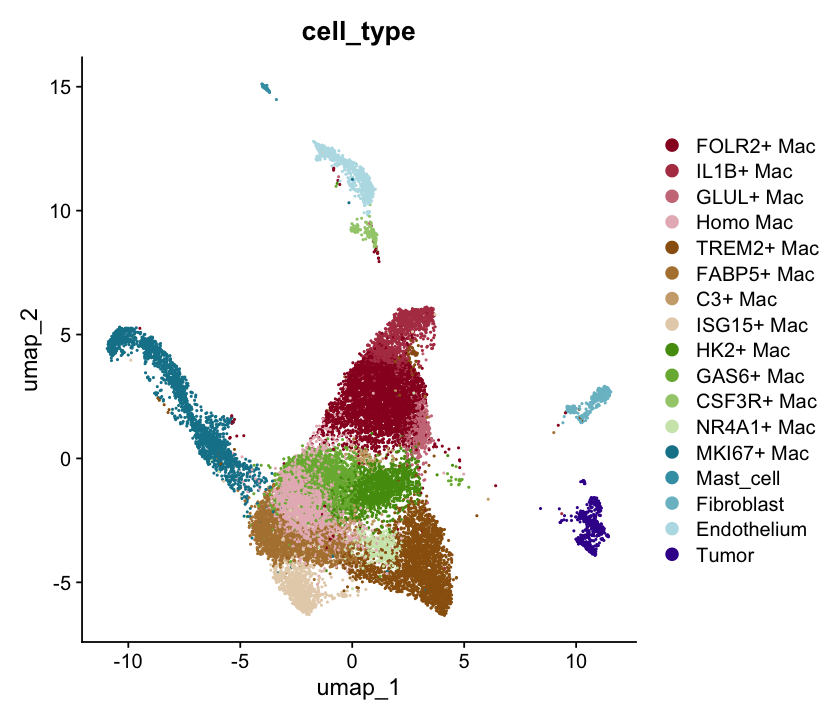

In [28]:
options(repr.plot.width = 7, repr.plot.height = 6)
DimPlot(all, group.by="cell_type", cols = pal)

In [29]:
# Extract cell type distribution data
meta <- all@meta.data
tab <- table(meta$cell_type, meta$orig.ident)
df_wide <- as.data.frame.matrix(tab)
df_wide$cell_type <- rownames(df_wide)

celltype_by_origident_df <- df_wide[, c("cell_type", "Assembloid", "VIO")]
celltype_by_origident_df

,cell_type,Assembloid,VIO
,<chr>,<int>,<int>
FOLR2+ Mac,FOLR2+ Mac,3547,160
IL1B+ Mac,IL1B+ Mac,1171,1
GLUL+ Mac,GLUL+ Mac,473,7
Homo Mac,Homo Mac,123,2761
TREM2+ Mac,TREM2+ Mac,641,1725
FABP5+ Mac,FABP5+ Mac,22,1902
C3+ Mac,C3+ Mac,9,137
ISG15+ Mac,ISG15+ Mac,15,862
HK2+ Mac,HK2+ Mac,159,1309


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


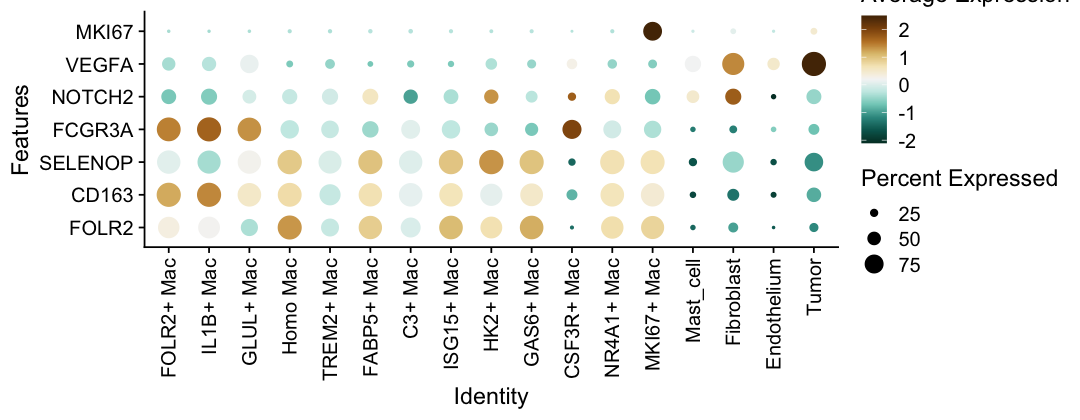

In [30]:
options(repr.plot.width = 9, repr.plot.height = 3.5)
library(RColorBrewer)
DotPlot(all, features=c(# FOLR2/resident identity
    "FOLR2","CD163","SELENOP",'FCGR3A','NOTCH2','VEGFA','MKI67'),
    group.by = "cell_type"
    ) + 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) + 
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) + coord_flip()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


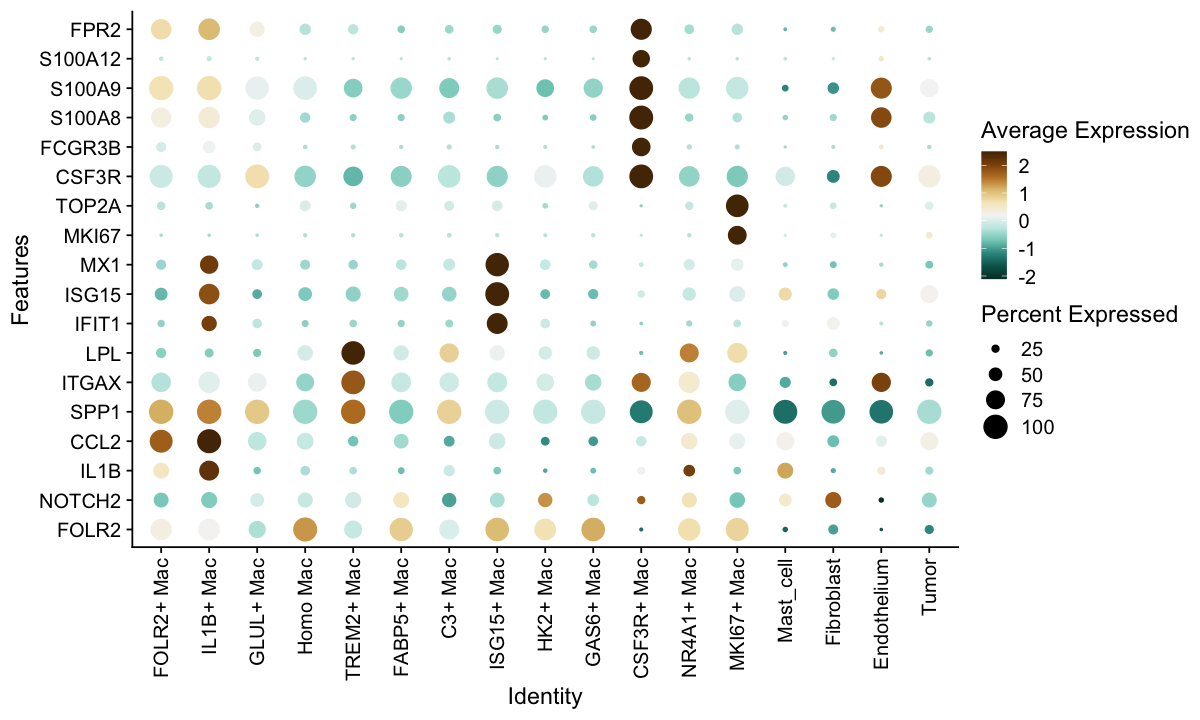

In [31]:
features <- c(
    'FOLR2','SLENOP','NOTCH2',
    'IL1B','CCL2',
    'SPP1','ITGAX','LPL',
    'IFIT1','ISG15','MX1',
    'MKI67','TOP2A',
    'CSF3R','FCGR3B', 'S100A8','S100A9','S100A12','FPR2'
)

features <- features[features %in% rownames(all)]

options(repr.plot.width = 10, repr.plot.height = 6)
DotPlot(all, features = features, group.by = "cell_type") +
    scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
    coord_flip()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


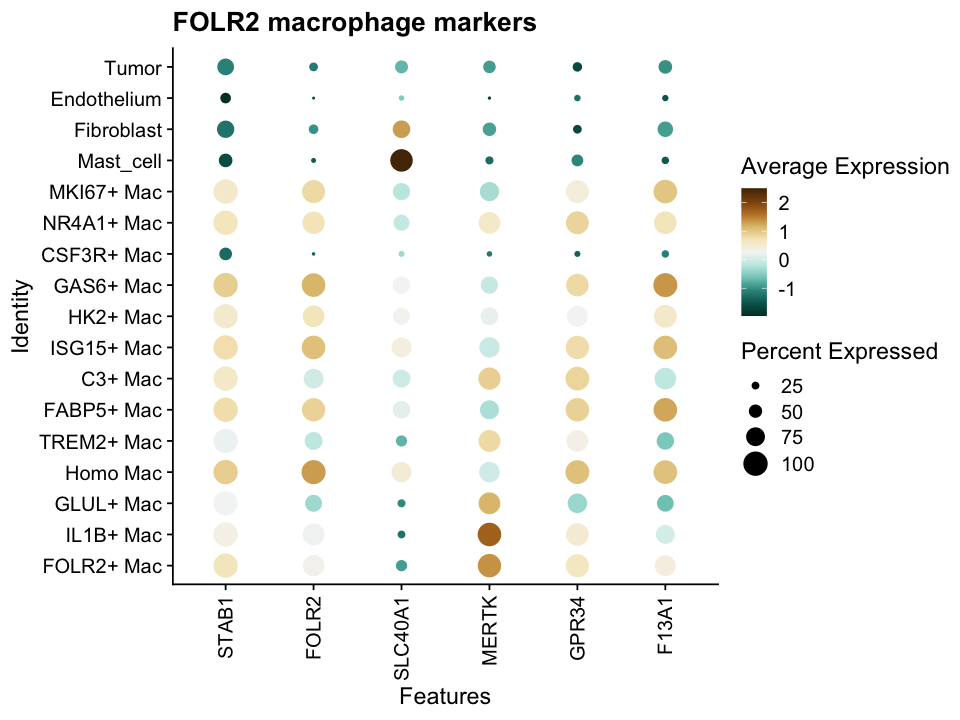

In [32]:
features <- c("STAB1", "FOLR2", "SLC40A1", "MERTK", "GPR34", "F13A1")
features <- features[features %in% rownames(all)]

options(repr.plot.width = 8, repr.plot.height = 6)
DotPlot(all, features = features, group.by = "cell_type") +
  scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
  ggtitle("FOLR2 macrophage markers")

Warning message:
“Different features in new layer data than already exists for scale.data”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Warning message:
“Different features in new layer data than already exists for scale.data”
Warning message:
“Number of dimensions changing from 50 to 30”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


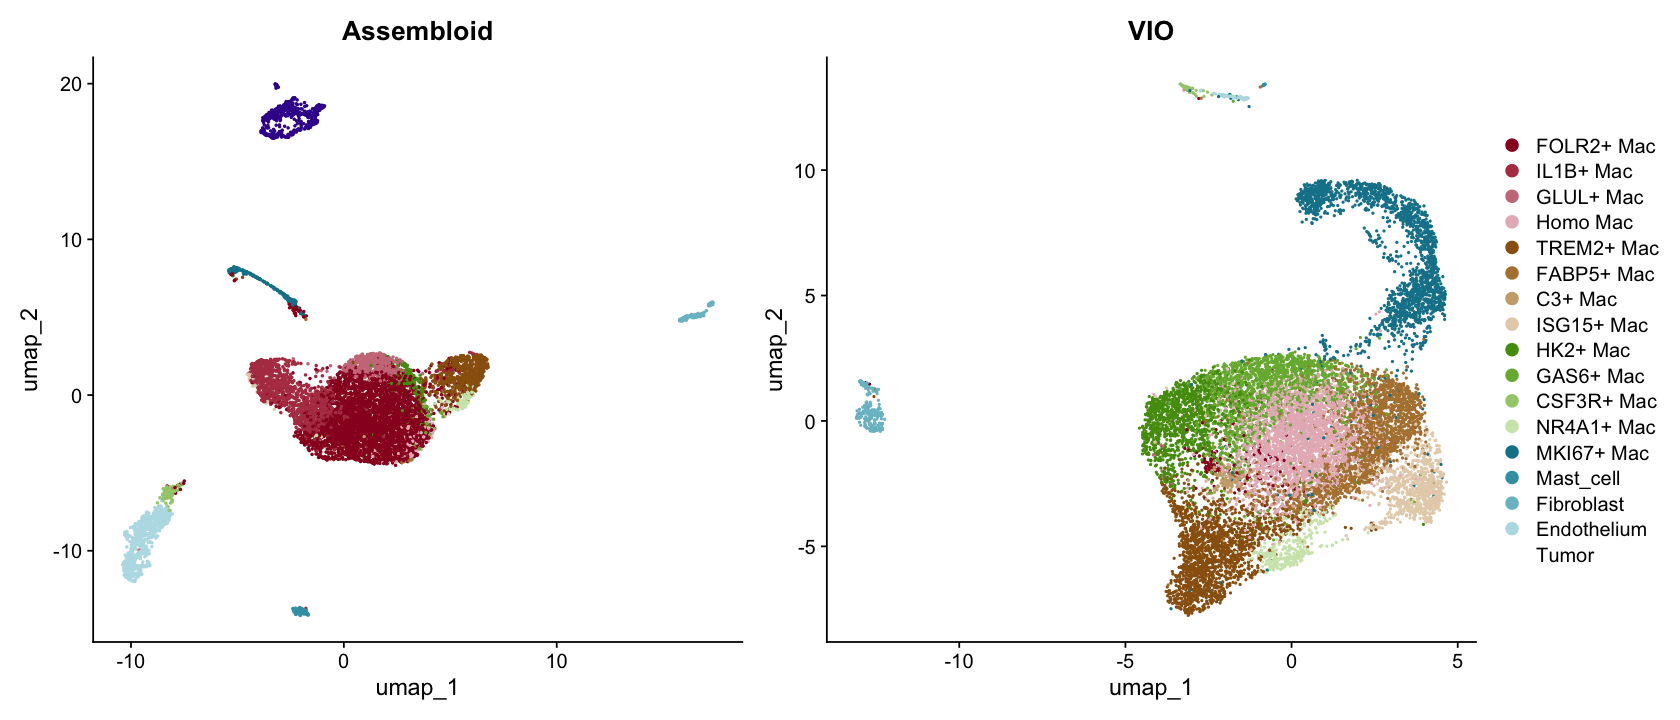

In [8]:
# Split by sample identity and independently recluster each subset
all_by_orig <- SplitObject(all, split.by = "orig.ident")

all_by_orig <- lapply(all_by_orig, function(object) {
  DefaultAssay(object) <- "RNA"
  object <- NormalizeData(object, verbose = FALSE)
  object <- FindVariableFeatures(object, selection.method = "vst", nfeatures = 2000, verbose = FALSE)
  object <- ScaleData(object, features = VariableFeatures(object), verbose = FALSE)
  object <- RunPCA(object, features = VariableFeatures(object), npcs = 30, verbose = FALSE)
  object <- FindNeighbors(object, dims = 1:30, verbose = FALSE)
  object <- FindClusters(object, resolution = 0.5, random.seed = 123, verbose = FALSE)
  object <- RunUMAP(object, dims = 1:30, seed.use = 123, verbose = FALSE)
  object
})

# Keep annotation colors and legend entries consistent across both subsets
umap_by_orig <- lapply(names(all_by_orig), function(sample_name) {
  DimPlot(
    all_by_orig[[sample_name]],
    reduction = "umap",
    group.by = "cell_type"
  ) +
    scale_color_manual(values = pal, limits = names(pal), drop = FALSE) +
    ggtitle(sample_name)
})

# Show one complete legend beside the final panel
if (length(umap_by_orig) > 1) {
  umap_by_orig[-length(umap_by_orig)] <- lapply(
    umap_by_orig[-length(umap_by_orig)],
    function(plot) plot + NoLegend()
  )
}

options(repr.plot.width = 14, repr.plot.height = 6)
wrap_plots(umap_by_orig, nrow = 1)

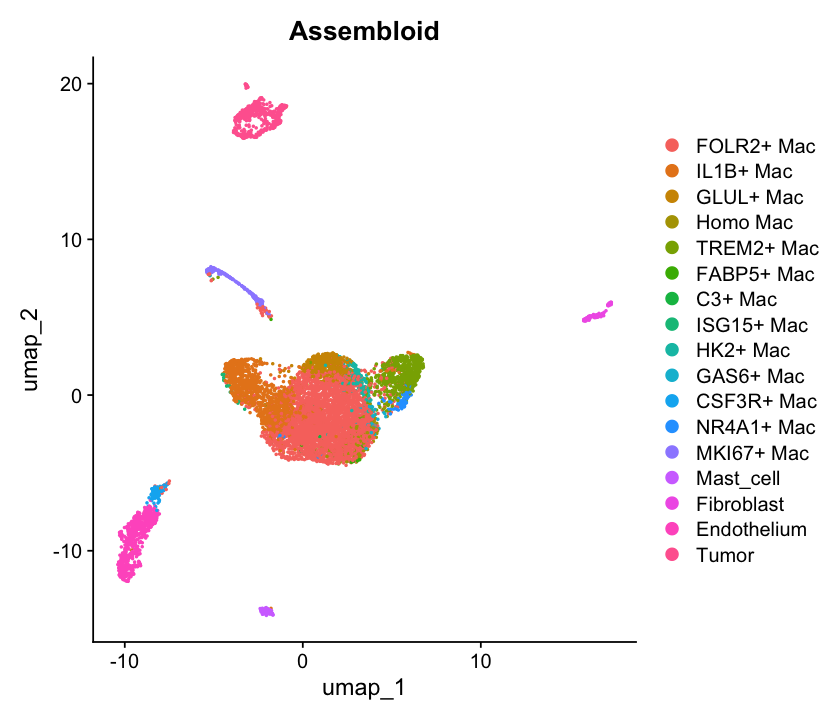

In [9]:
# Show the existing Assembloid UMAP with Seurat's default colors
stopifnot(
  "Assembloid" %in% names(all_by_orig),
  "umap" %in% Reductions(all_by_orig[["Assembloid"]])
)

options(repr.plot.width = 7, repr.plot.height = 6)
DimPlot(
  all_by_orig[["Assembloid"]],
  reduction = "umap",
  group.by = "cell_type"
) +
  ggtitle("Assembloid")